In [8]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [9]:
from google.colab import files

uploaded = files.upload()

Saving gambar usm - Copy (2).jpg to gambar usm - Copy (2).jpg
Saving gambar usm - Copy (3).jpg to gambar usm - Copy (3).jpg
Saving gambar usm - Copy (4).jpg to gambar usm - Copy (4).jpg
Saving gambar usm - Copy (5).jpg to gambar usm - Copy (5).jpg
Saving gambar usm - Copy (6).jpg to gambar usm - Copy (6).jpg
Saving gambar usm - Copy (7).jpg to gambar usm - Copy (7).jpg
Saving gambar usm - Copy (8).jpg to gambar usm - Copy (8).jpg
Saving gambar usm - Copy (9).jpg to gambar usm - Copy (9).jpg
Saving gambar usm - Copy (10).jpg to gambar usm - Copy (10).jpg
Saving gambar usm - Copy (11).jpg to gambar usm - Copy (11).jpg
Saving gambar usm - Copy (12).jpg to gambar usm - Copy (12).jpg
Saving gambar usm - Copy (13).jpg to gambar usm - Copy (13).jpg
Saving gambar usm - Copy (14).jpg to gambar usm - Copy (14).jpg
Saving gambar usm - Copy (15).jpg to gambar usm - Copy (15).jpg
Saving gambar usm - Copy (16).jpg to gambar usm - Copy (16).jpg
Saving gambar usm - Copy (17).jpg to gambar usm - Copy (

In [10]:
os.makedirs("dataset", exist_ok=True)

for filename in uploaded.keys():
    with open(os.path.join("dataset", filename), "wb") as f:
        f.write(uploaded[filename])

In [11]:
def load_images_from_folder(folder):
    images = []

    if not os.path.exists(folder):
        print("Folder tidak ditemukan")
        return images

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        img = cv2.imread(path)

        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)

    return images

images = load_images_from_folder("dataset")

print("Jumlah citra:", len(images))

Jumlah citra: 20


In [12]:
def translation(img, tx, ty):
    h, w = img.shape
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h))

In [13]:
def rotation(img, angle):
    h, w = img.shape
    center = (w//2, h//2)
    M = cv2.getRotationMatrix2D(center, angle, 1)
    return cv2.warpAffine(img, M, (w, h))

In [14]:
def scaling(img, fx, fy):
    return cv2.resize(img, None, fx=fx, fy=fy)

In [15]:
def shearing(img, shear):
    h, w = img.shape
    M = np.float32([[1, shear, 0],
                    [0, 1, 0]])
    return cv2.warpAffine(img, M, (int(w + shear*h), h))

In [16]:
def reflection(img, mode):
    return cv2.flip(img, mode)

In [17]:
def affine_transform(img):
    h, w = img.shape
    pts1 = np.float32([[50,50],[200,50],[50,200]])
    pts2 = np.float32([[10,100],[200,50],[100,250]])
    M = cv2.getAffineTransform(pts1, pts2)
    return cv2.warpAffine(img, M, (w, h))

In [18]:
def perspective_transform(img):
    h, w = img.shape
    pts1 = np.float32([[0,0],[w,0],[0,h],[w,h]])
    pts2 = np.float32([[50,50],[w-50,0],[0,h],[w,h-50]])
    M = cv2.getPerspectiveTransform(pts1, pts2)
    return cv2.warpPerspective(img, M, (w, h))

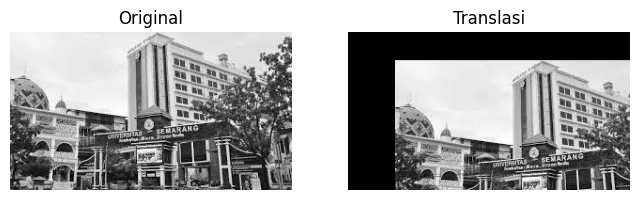

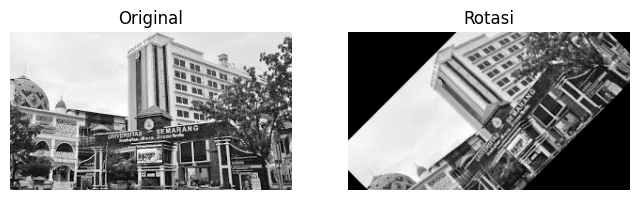

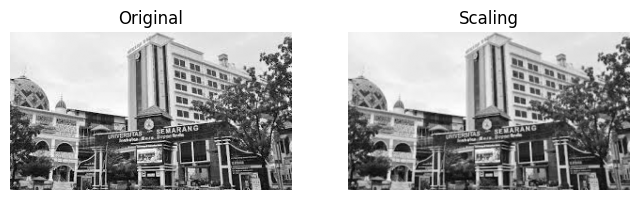

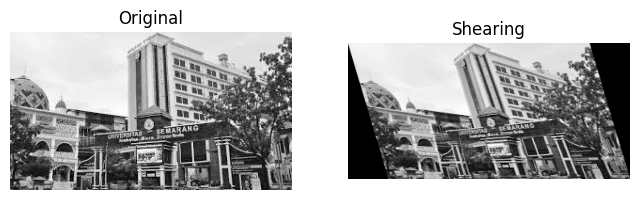

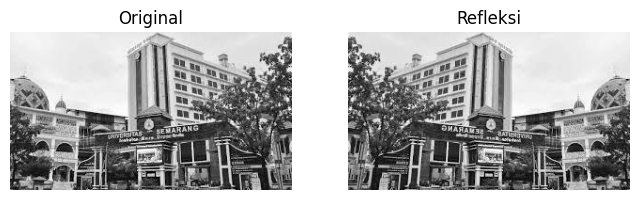

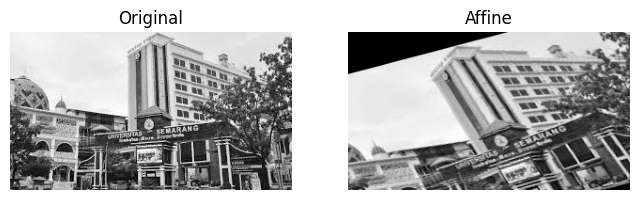

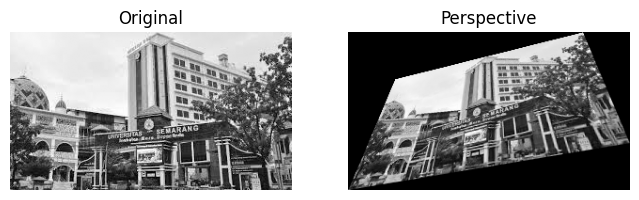

In [19]:
def show_images(original, transformed, title):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(transformed, cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.show()

img = images[0]

show_images(img, translation(img,50,30), "Translasi")
show_images(img, rotation(img,45), "Rotasi")
show_images(img, scaling(img,1.5,1.5), "Scaling")
show_images(img, shearing(img,0.3), "Shearing")
show_images(img, reflection(img,1), "Refleksi")
show_images(img, affine_transform(img), "Affine")
show_images(img, perspective_transform(img), "Perspective")

In [20]:
os.makedirs("output", exist_ok=True)

for i, img in enumerate(images):

    cv2.imwrite(f"output/trans_{i}.jpg", translation(img,50,30))
    cv2.imwrite(f"output/rot_{i}.jpg", rotation(img,45))
    cv2.imwrite(f"output/scale_{i}.jpg", scaling(img,1.5,1.5))
    cv2.imwrite(f"output/shear_{i}.jpg", shearing(img,0.3))
    cv2.imwrite(f"output/ref_{i}.jpg", reflection(img,1))
    cv2.imwrite(f"output/affine_{i}.jpg", affine_transform(img))
    cv2.imwrite(f"output/pers_{i}.jpg", perspective_transform(img))

print("Semua hasil berhasil disimpan di folder output")

Semua hasil berhasil disimpan di folder output


In [21]:
!zip -r output.zip output
from google.colab import files
files.download("output.zip")

  adding: output/ (stored 0%)
  adding: output/scale_5.jpg (deflated 1%)
  adding: output/scale_13.jpg (deflated 1%)
  adding: output/affine_9.jpg (deflated 1%)
  adding: output/trans_18.jpg (deflated 1%)
  adding: output/scale_14.jpg (deflated 1%)
  adding: output/rot_12.jpg (deflated 1%)
  adding: output/ref_17.jpg (deflated 1%)
  adding: output/scale_0.jpg (deflated 1%)
  adding: output/shear_11.jpg (deflated 1%)
  adding: output/rot_9.jpg (deflated 1%)
  adding: output/ref_16.jpg (deflated 1%)
  adding: output/pers_1.jpg (deflated 1%)
  adding: output/trans_2.jpg (deflated 1%)
  adding: output/ref_15.jpg (deflated 1%)
  adding: output/pers_7.jpg (deflated 1%)
  adding: output/pers_9.jpg (deflated 1%)
  adding: output/ref_3.jpg (deflated 1%)
  adding: output/shear_8.jpg (deflated 1%)
  adding: output/pers_16.jpg (deflated 1%)
  adding: output/pers_3.jpg (deflated 1%)
  adding: output/rot_13.jpg (deflated 1%)
  adding: output/rot_5.jpg (deflated 1%)
  adding: output/trans_5.jpg (defl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>